In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../DATA/lamborghini_sales_2020_2025.csv')

In [3]:
df.head()

,Model,Year,Region,Color,Fuel Type,Base Price (USD),Horsepower,Sales Volume,Turbo (Yes/No)
0,Urus,2020,EMEA,Black,Gasoline,230000,641,4500,Yes
1,Urus,2020,Americas,White,Gasoline,240000,641,4800,Yes
2,Urus,2020,APAC,Red,Gasoline,235000,641,2700,Yes
3,Huracán,2020,EMEA,Yellow,Gasoline,260000,631,2500,Yes
4,Huracán,2020,Americas,Orange,Gasoline,270000,631,2600,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Model             54 non-null     object
 1   Year              54 non-null     int64 
 2   Region            54 non-null     object
 3   Color             54 non-null     object
 4   Fuel Type         54 non-null     object
 5   Base Price (USD)  54 non-null     int64 
 6   Horsepower        54 non-null     int64 
 7   Sales Volume      54 non-null     int64 
 8   Turbo (Yes/No)    54 non-null     object
dtypes: int64(4), object(5)
memory usage: 3.9+ KB


In [5]:
df['Make'] = 'Lamborghini'

In [6]:
df.head()

,Model,Year,Region,Color,Fuel Type,Base Price (USD),Horsepower,Sales Volume,Turbo (Yes/No),Make
0,Urus,2020,EMEA,Black,Gasoline,230000,641,4500,Yes,Lamborghini
1,Urus,2020,Americas,White,Gasoline,240000,641,4800,Yes,Lamborghini
2,Urus,2020,APAC,Red,Gasoline,235000,641,2700,Yes,Lamborghini
3,Huracán,2020,EMEA,Yellow,Gasoline,260000,631,2500,Yes,Lamborghini
4,Huracán,2020,Americas,Orange,Gasoline,270000,631,2600,Yes,Lamborghini


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Model             54 non-null     object
 1   Year              54 non-null     int64 
 2   Region            54 non-null     object
 3   Color             54 non-null     object
 4   Fuel Type         54 non-null     object
 5   Base Price (USD)  54 non-null     int64 
 6   Horsepower        54 non-null     int64 
 7   Sales Volume      54 non-null     int64 
 8   Turbo (Yes/No)    54 non-null     object
 9   Make              54 non-null     object
dtypes: int64(4), object(6)
memory usage: 4.3+ KB


<Axes: xlabel='Base Price (USD)', ylabel='Count'>

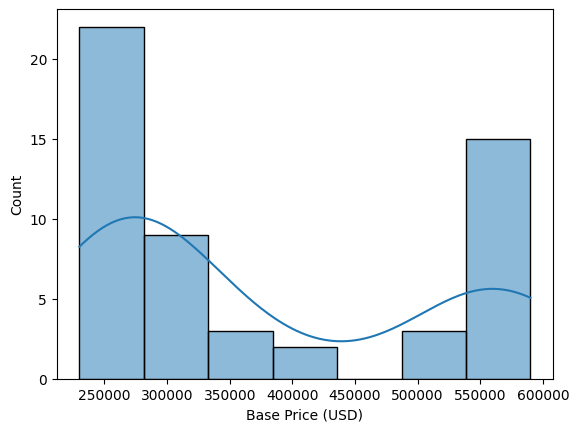

In [8]:
sns.histplot(df['Base Price (USD)'], kde=True)

<Axes: >

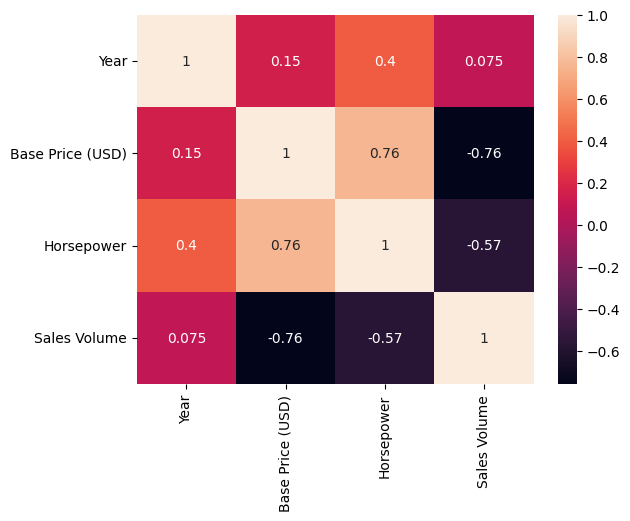

In [9]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

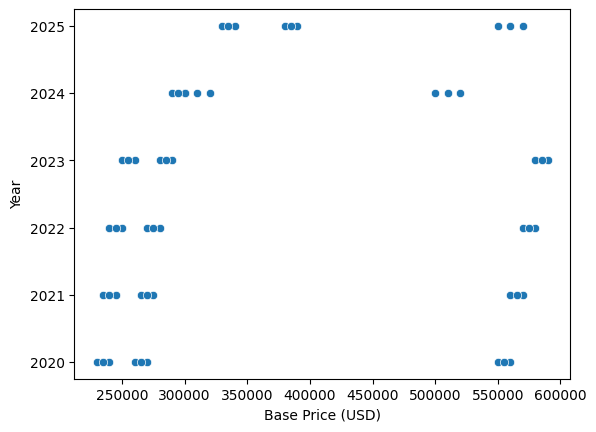

In [10]:
sns.scatterplot(x='Base Price (USD)', y='Year', data=df);

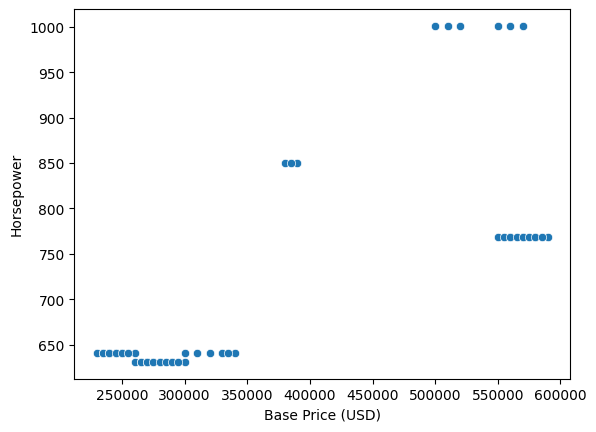

In [11]:
sns.scatterplot(x='Base Price (USD)', y='Horsepower', data=df);

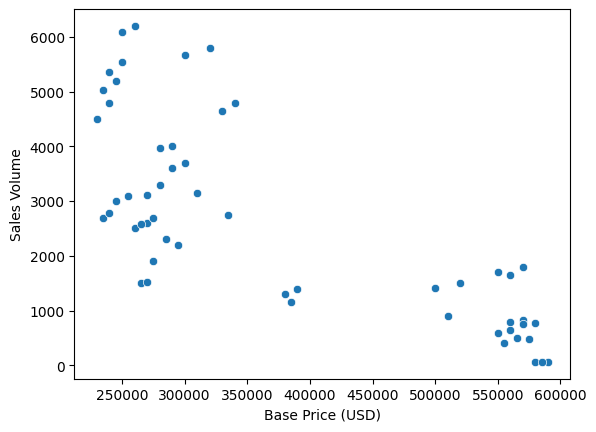

In [12]:
sns.scatterplot(x='Base Price (USD)', y='Sales Volume', data=df);

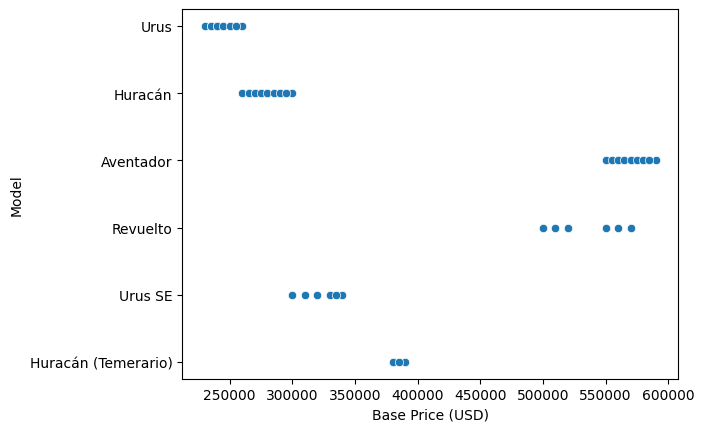

In [13]:
sns.scatterplot(x='Base Price (USD)', y='Model', data=df);

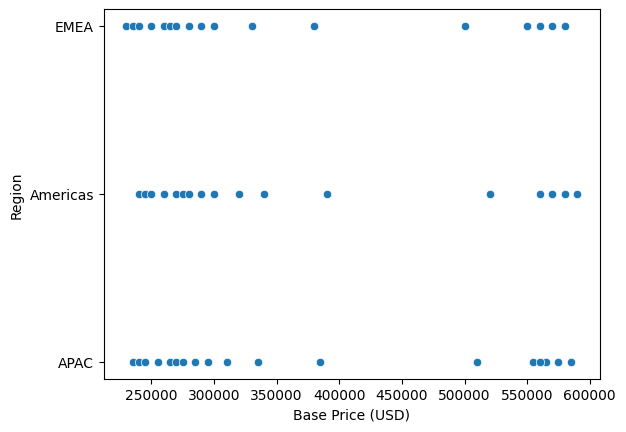

In [14]:
sns.scatterplot(x='Base Price (USD)', y='Region', data=df);

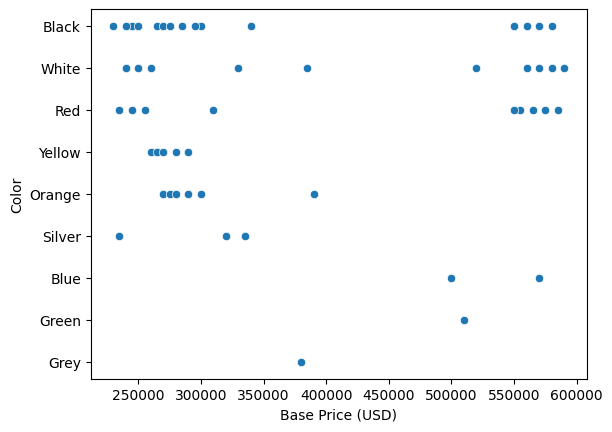

In [15]:
sns.scatterplot(x='Base Price (USD)', y='Color', data=df);

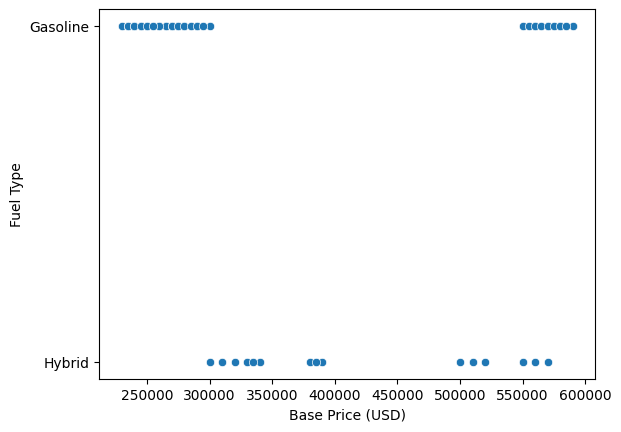

In [16]:
sns.scatterplot(x='Base Price (USD)', y='Fuel Type', data=df);

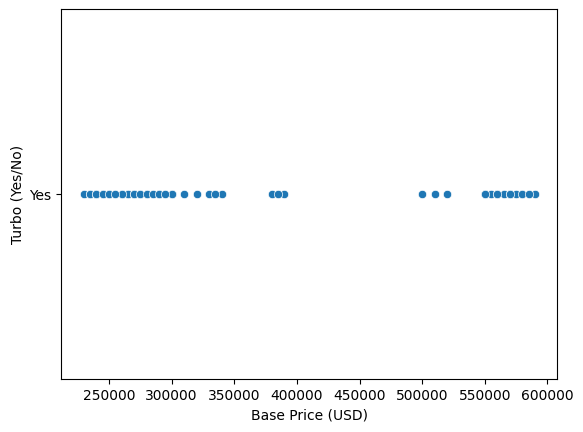

In [17]:
sns.scatterplot(x='Base Price (USD)', y='Turbo (Yes/No)', data=df);

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, OneHotEncoder
from sklearn.linear_model import ElasticNetCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.impute import KNNImputer

In [19]:
X = df.drop('Base Price (USD)', axis=1)

In [20]:
y = df['Base Price (USD)']

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=104)

In [22]:
num_features = X_train.select_dtypes(exclude='object').columns.tolist()
cat_features = X_train.select_dtypes(include='object').columns.tolist()

In [23]:
num_features

['Year', 'Horsepower', 'Sales Volume']

In [24]:
cat_features

['Model', 'Region', 'Color', 'Fuel Type', 'Turbo (Yes/No)', 'Make']

In [25]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features),
        ('num', StandardScaler(), num_features)
    ],
    remainder='passthrough'
)

In [26]:
pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('model', ElasticNetCV(cv=10, n_jobs=-1, l1_ratio=[.1, .5, .7,.9, .95, .99, 1.0], max_iter=1_000_000))
])

In [27]:
pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('poly', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tran

In [28]:
y_train_pred = pipe.predict(X_train)
y_pred = pipe.predict(X_test)

In [29]:
best_model = pipe.named_steps['model']
print(f"Лучшее значение alpha: {best_model.alpha_}")
print(f"Лучшее значение l1_ratio: {best_model.l1_ratio_}")

Лучшее значение alpha: 129.72673766572953
Лучшее значение l1_ratio: 1.0


In [30]:
MAE = mean_absolute_error(y_test, y_pred)
MSE = mean_squared_error(y_test, y_pred)
RMSE = np.sqrt(MSE)
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_pred)

In [31]:
MAE

2754.323055481737

In [32]:
MSE

8904088.723109381

In [33]:
RMSE

np.float64(2983.971970898752)

In [34]:
r2_train

0.9997476975809099

In [35]:
r2_test

0.9992788589560586

In [36]:
df['Base Price (USD)'].mean()

np.float64(374722.22222222225)

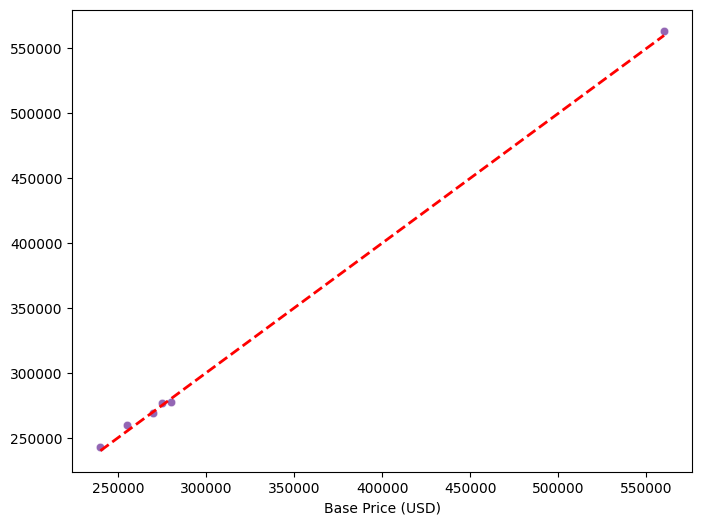

In [37]:
plt.figure(figsize=(8, 6))

sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, color='indigo')

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2);

In [38]:
pipe.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('poly', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tran

In [39]:
y_pred_full = pipe.predict(X)

In [40]:
best_final_model = pipe.named_steps['model']
print(f"Лучшее значение alpha: {best_final_model.alpha_}")
print(f"Лучшее значение l1_ratio: {best_final_model.l1_ratio_}")

Лучшее значение alpha: 145.30335352095602
Лучшее значение l1_ratio: 1.0


In [41]:
r2_full = r2_score(y, y_pred_full)

In [42]:
r2_full

0.9996923993421061

In [43]:
df['Model'].unique()

array(['Urus', 'Huracán', 'Aventador', 'Revuelto', 'Urus SE',
       'Huracán (Temerario)'], dtype=object)

In [44]:
df['Region'].unique()

array(['EMEA', 'Americas', 'APAC'], dtype=object)

In [45]:
df['Color'].unique()

array(['Black', 'White', 'Red', 'Yellow', 'Orange', 'Silver', 'Blue',
       'Green', 'Grey'], dtype=object)

In [46]:
df['Fuel Type'].unique()

array(['Gasoline', 'Hybrid'], dtype=object)

In [47]:
df[df['Base Price (USD)'] == 590000]

,Model,Year,Region,Color,Fuel Type,Base Price (USD),Horsepower,Sales Volume,Turbo (Yes/No),Make
34,Aventador,2023,Americas,White,Gasoline,590000,769,63,Yes,Lamborghini


In [48]:
cheap_spec = pd.DataFrame([{
    'Model': 'Urus',
    'Year': 2024,
    'Region': 'Americas',
    'Color': 'Black',
    'Fuel Type': 'Gasoline',
    'Horsepower': 641,
    'Sales Volume': 4800,
    'Turbo (Yes/No)': 'Yes',
    'Make': 'Lamborghini'
}])

expensive_spec = pd.DataFrame([{
    'Model': 'Aventador',
    'Year': 2024,
    'Region': 'Americas',
    'Color': 'Black',
    'Fuel Type': 'Gasoline',
    'Horsepower': 769,
    'Sales Volume': 63, 
    'Turbo (Yes/No)': 'Yes',
    'Make': 'Lamborghini'
}])

In [49]:
cheap_spec

,Model,Year,Region,Color,Fuel Type,Horsepower,Sales Volume,Turbo (Yes/No),Make
0,Urus,2024,Americas,Black,Gasoline,641,4800,Yes,Lamborghini


In [50]:
expensive_spec

,Model,Year,Region,Color,Fuel Type,Horsepower,Sales Volume,Turbo (Yes/No),Make
0,Aventador,2024,Americas,Black,Gasoline,769,63,Yes,Lamborghini


In [51]:
predicted_cheap = pipe.predict(cheap_spec)[0]

In [52]:
predicted_expensive = pipe.predict(expensive_spec)[0]

In [53]:
print(f"--- ПРЕДСКАЗАННАЯ ЦЕНА ДЛЯ ДЕШЕВОЙ LAMBO: ${predicted_cheap:,.2f}")
print(f"--- ПРЕДСКАЗАННАЯ ЦЕНА ДЛЯ ДОРОГОЙ LAMBO: ${predicted_expensive:,.2f}")

--- ПРЕДСКАЗАННАЯ ЦЕНА ДЛЯ ДЕШЕВОЙ LAMBO: $276,467.97
--- ПРЕДСКАЗАННАЯ ЦЕНА ДЛЯ ДОРОГОЙ LAMBO: $604,109.23


In [54]:
import json
import os

advanced_report = {
    "project": "Lamborghini Price Prediction",
    "model": "ElasticNetCV",
    "trained_date": '2026-07',
    "test_parameters": {
        "alpha": best_model.alpha_,
        "l1_ratio": best_model.l1_ratio_,
        "cv": best_model.cv
    },
    "final_parameters": {
        "alpha": best_final_model.alpha_,
        "l1_ratio":  best_final_model.l1_ratio_,
        "cv": best_final_model.cv
    },
    "metrics": {
        "RMSE": RMSE,
        "MAE": MAE,
        "R2_train": r2_train,
        "R2_test": r2_test,
        "R2_full": r2_full,
        "Mean_Lamborghini_Price": df['Base Price (USD)'].mean()
    }
}


filename = "model_description.json"

with open(filename, "w", encoding="utf-8") as f:
    json.dump(advanced_report, f, indent=4, ensure_ascii=False)

In [55]:
from joblib import dump, load

In [56]:
dump(pipe, 'model/lamborghini_price_prediction_elastic_net_cv_2026_v1.pkl')

['model/lamborghini_price_prediction_elastic_net_cv_2026_v1.pkl']

In [57]:
loaded_pipe = load('model/lamborghini_price_prediction_elastic_net_cv_2026_v1.pkl')

In [58]:
print(f"--- ПРЕДСКАЗАННАЯ ЦЕНА ДЛЯ ДОРОГОЙ LAMBO: ${loaded_pipe.predict(expensive_spec)[0]:,.2f}")

--- ПРЕДСКАЗАННАЯ ЦЕНА ДЛЯ ДОРОГОЙ LAMBO: $604,109.23
